# RF Seeing Eye Chart

This notebook creates a placeholder 10 MHz OFDM QPSK waveform, builds a seeing-eye style composite at 50 Msps by sweeping bandwidth, pulse duration, and SNR, and exports the result as SigMF.

The layout is frequency from left to right and time from top to bottom so the spectrogram behaves like an RF eye chart for detector validation.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.io import loadmat, savemat

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['image.cmap'] = 'viridis'

WORKSPACE_ROOT = Path('/home/sat3737/holoscan_demo_workspace')
NOTEBOOK_DIR = WORKSPACE_ROOT / 'holohub-dev' / 'notebooks'
ARTIFACT_DIR = NOTEBOOK_DIR / 'validator_artifacts' / 'rf_seeing_eye_chart'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

OFDM_WAVEFORM_PATH = ARTIFACT_DIR / 'placeholder_ofdm_qpsk_10mhz.mat'
FM_WAVEFORM_PATH = ARTIFACT_DIR / 'placeholder_fm_200khz.mat'
QPSK_WAVEFORM_PATH = ARTIFACT_DIR / 'placeholder_qpsk_3p375mhz.mat'
SIGMF_STEM = ARTIFACT_DIR / 'RF_seeing_eye_exam_transmit'

FINAL_SAMPLE_RATE_HZ = 50_000_000
SOURCE_SAMPLE_RATE_HZ = 10_000_000
SOURCE_BANDWIDTH_HZ = 10_000_000
PLACEHOLDER_DURATION_S = 0.020

BANDWIDTHS_HZ = np.array([20_000_000, 10_000_000, 5_000_000, 1_000_000, 200_000, 20_000], dtype=float)
REFERENCE_BANDWIDTH_HZ = float(np.max(BANDWIDTHS_HZ))
GUARD_BAND_HZ = 1_000_000
PULSE_DURATIONS_S = np.array([100e-3, 50e-3, 5e-3, 1e-3, 100e-6], dtype=float)
ROW_GUARD_S = 10e-3
SNR_DB_LEVELS = np.array([20.0, 10.0, 0.0], dtype=float)
SNR_BLOCK_GUARD_S = 25e-3
WAVEFORM_BLOCK_GUARD_S = 50e-3
BASE_NOISE_POWER = 1.0
RNG_SEED = 7

WAVEFORM_PATHS = [OFDM_WAVEFORM_PATH, FM_WAVEFORM_PATH, QPSK_WAVEFORM_PATH]

def human_hz(value_hz: float) -> str:
    if value_hz >= 1e6:
        return f'{value_hz / 1e6:.3g} MHz'
    if value_hz >= 1e3:
        return f'{value_hz / 1e3:.3g} kHz'
    return f'{value_hz:.3g} Hz'

def human_time(value_s: float) -> str:
    if value_s >= 1e-3:
        return f'{value_s * 1e3:.3g} ms'
    return f'{value_s * 1e6:.3g} us'

def compute_center_frequencies(bandwidths_hz: np.ndarray, guard_band_hz: float) -> np.ndarray:
    total_span_hz = float(np.sum(bandwidths_hz) + guard_band_hz * (len(bandwidths_hz) - 1))
    cursor_hz = -0.5 * total_span_hz
    centers_hz: list[float] = []
    for bandwidth_hz in bandwidths_hz:
        centers_hz.append(cursor_hz + 0.5 * float(bandwidth_hz))
        cursor_hz += float(bandwidth_hz) + guard_band_hz
    return np.asarray(centers_hz, dtype=float)

CENTER_FREQUENCIES_HZ = compute_center_frequencies(BANDWIDTHS_HZ, GUARD_BAND_HZ)
assert np.max(np.abs(CENTER_FREQUENCIES_HZ) + 0.5 * BANDWIDTHS_HZ) < FINAL_SAMPLE_RATE_HZ / 2, 'Frequency layout exceeds Nyquist.'

print('Artifact directory:', ARTIFACT_DIR)
print('Waveform library:', ', '.join(path.stem for path in WAVEFORM_PATHS))
print('Bandwidth sweep:', ', '.join(human_hz(value) for value in BANDWIDTHS_HZ))
print('Reference bandwidth for peak normalization:', human_hz(REFERENCE_BANDWIDTH_HZ))
print('Pulse durations:', ', '.join(human_time(value) for value in PULSE_DURATIONS_S))
print('SNR levels:', ', '.join(f'{value:.0f} dB' for value in SNR_DB_LEVELS))
print('Centered carrier locations (MHz):', np.round(CENTER_FREQUENCIES_HZ / 1e6, 3))

Artifact directory: /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/validator_artifacts/rf_seeing_eye_chart
Waveform library: placeholder_ofdm_qpsk_10mhz, placeholder_fm_200khz, placeholder_qpsk_3p375mhz
Bandwidth sweep: 20 MHz, 10 MHz, 5 MHz, 1 MHz, 200 kHz, 20 kHz
Reference bandwidth for peak normalization: 20 MHz
Pulse durations: 100 ms, 50 ms, 5 ms, 1 ms, 100 us
SNR levels: 20 dB, 10 dB, 0 dB
Centered carrier locations (MHz): [-10.61   5.39  13.89  17.89  19.49  20.6 ]


In [2]:
def generate_ofdm_qpsk(sample_rate_hz: float, duration_s: float, occupied_bandwidth_hz: float, seed: int) -> tuple[np.ndarray, dict[str, float | int | str]]:
    rng = np.random.default_rng(seed)
    fft_size = 1024
    cp_len = 72
    subcarrier_spacing_hz = sample_rate_hz / fft_size
    active_bins = int(np.floor(occupied_bandwidth_hz / subcarrier_spacing_hz))
    active_bins = max(8, min(active_bins - (active_bins % 2), fft_size - 2))
    symbol_len = fft_size + cp_len
    num_symbols = int(np.ceil(duration_s * sample_rate_hz / symbol_len)) + 1

    constellation = np.array([1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j], dtype=np.complex64) / np.sqrt(2.0)
    freq_grid = np.zeros((num_symbols, fft_size), dtype=np.complex64)
    half_active = active_bins // 2
    positive_bins = np.arange(1, half_active + 1)
    negative_bins = fft_size - np.arange(half_active, 0, -1)
    used_bins = np.concatenate([negative_bins, positive_bins])
    freq_grid[:, used_bins] = rng.choice(constellation, size=(num_symbols, active_bins))

    time_symbols = np.fft.ifft(freq_grid, axis=1, norm='ortho')
    cyclic_prefix = time_symbols[:, -cp_len:]
    waveform = np.concatenate([cyclic_prefix, time_symbols], axis=1).reshape(-1)
    output_samples = int(round(duration_s * sample_rate_hz))
    waveform = waveform[:output_samples]
    waveform /= np.sqrt(np.mean(np.abs(waveform) ** 2))

    metadata = {
        'waveform_family': 'ofdm_qpsk',
        'sample_rate_hz': float(sample_rate_hz),
        'bandwidth_hz': float(occupied_bandwidth_hz),
        'fft_size': int(fft_size),
        'cp_len': int(cp_len),
        'duration_s': float(duration_s),
        'seed': int(seed),
    }
    return waveform.astype(np.complex64), metadata

def root_raised_cosine_taps(samples_per_symbol: int, rolloff: float, span_symbols: int) -> np.ndarray:
    time_index = np.arange(-span_symbols * samples_per_symbol, span_symbols * samples_per_symbol + 1, dtype=np.float64)
    time_index /= samples_per_symbol
    taps = np.zeros_like(time_index)

    for idx, value in enumerate(time_index):
        if np.isclose(value, 0.0):
            taps[idx] = 1.0 + rolloff * (4.0 / np.pi - 1.0)
            continue
        if rolloff > 0 and np.isclose(abs(value), 1.0 / (4.0 * rolloff)):
            taps[idx] = (
                rolloff
                / np.sqrt(2.0)
                * (
                    (1.0 + 2.0 / np.pi) * np.sin(np.pi / (4.0 * rolloff))
                    + (1.0 - 2.0 / np.pi) * np.cos(np.pi / (4.0 * rolloff))
                )
            )
            continue
        numerator = np.sin(np.pi * value * (1.0 - rolloff))
        numerator += 4.0 * rolloff * value * np.cos(np.pi * value * (1.0 + rolloff))
        denominator = np.pi * value * (1.0 - (4.0 * rolloff * value) ** 2)
        taps[idx] = numerator / denominator

    taps /= np.sqrt(np.sum(taps ** 2))
    return taps.astype(np.float32)

def generate_shaped_qpsk(
    sample_rate_hz: float,
    duration_s: float,
    symbol_rate_hz: float,
    rolloff: float,
    seed: int,
) -> tuple[np.ndarray, dict[str, float | int | str]]:
    samples_per_symbol = int(round(sample_rate_hz / symbol_rate_hz))
    if not np.isclose(symbol_rate_hz * samples_per_symbol, sample_rate_hz):
        raise ValueError('sample_rate_hz must be an integer multiple of symbol_rate_hz for the placeholder QPSK generator.')

    rng = np.random.default_rng(seed)
    span_symbols = 10
    output_samples = int(round(duration_s * sample_rate_hz))
    num_symbols = int(np.ceil(output_samples / samples_per_symbol)) + 2 * span_symbols
    constellation = np.array([1 + 1j, 1 - 1j, -1 + 1j, -1 - 1j], dtype=np.complex64) / np.sqrt(2.0)
    symbols = rng.choice(constellation, size=num_symbols)

    upsampled = np.zeros(num_symbols * samples_per_symbol, dtype=np.complex64)
    upsampled[::samples_per_symbol] = symbols
    taps = root_raised_cosine_taps(samples_per_symbol=samples_per_symbol, rolloff=rolloff, span_symbols=span_symbols)
    waveform = np.convolve(upsampled, taps, mode='same')
    waveform = waveform[:output_samples]
    waveform /= np.sqrt(np.mean(np.abs(waveform) ** 2))

    metadata = {
        'waveform_family': 'qpsk',
        'sample_rate_hz': float(sample_rate_hz),
        'symbol_rate_hz': float(symbol_rate_hz),
        'rolloff': float(rolloff),
        'bandwidth_hz': float(symbol_rate_hz * (1.0 + rolloff)),
        'duration_s': float(duration_s),
        'seed': int(seed),
    }
    return waveform.astype(np.complex64), metadata

def generate_fm(
    sample_rate_hz: float,
    duration_s: float,
    freq_deviation_hz: float,
    seed: int,
) -> tuple[np.ndarray, dict[str, float | int | str]]:
    rng = np.random.default_rng(seed)
    output_samples = int(round(duration_s * sample_rate_hz))
    time_axis = np.arange(output_samples, dtype=np.float64) / sample_rate_hz
    message = (
        0.55 * np.sin(2.0 * np.pi * 1_200.0 * time_axis)
        + 0.30 * np.sin(2.0 * np.pi * 3_700.0 * time_axis + 0.4)
        + 0.15 * signal.lfilter([1.0], [1.0, -0.985], rng.standard_normal(output_samples))
    )
    message /= np.max(np.abs(message))
    phase = 2.0 * np.pi * freq_deviation_hz * np.cumsum(message) / sample_rate_hz
    waveform = np.exp(1j * phase).astype(np.complex64)
    waveform /= np.sqrt(np.mean(np.abs(waveform) ** 2))

    metadata = {
        'waveform_family': 'fm',
        'sample_rate_hz': float(sample_rate_hz),
        'freq_deviation_hz': float(freq_deviation_hz),
        'bandwidth_hz': float(2.0 * (freq_deviation_hz + 4_000.0)),
        'duration_s': float(duration_s),
        'seed': int(seed),
    }
    return waveform, metadata

def save_waveform_mat(path: Path, waveform: np.ndarray, metadata: dict[str, float | int | str], description: str) -> tuple[np.ndarray, dict[str, float | int | str]]:
    savemat(
        path,
        {
            'iq': waveform.astype(np.complex64),
            'sample_rate_hz': np.asarray([[metadata['sample_rate_hz']]], dtype=np.float64),
            'bandwidth_hz': np.asarray([[metadata['bandwidth_hz']]], dtype=np.float64),
            'description': np.asarray([description]),
        },
    )
    return waveform, metadata

def save_placeholder_waveform(path: Path) -> tuple[np.ndarray, dict[str, float | int | str]]:
    waveform, metadata = generate_ofdm_qpsk(
        sample_rate_hz=SOURCE_SAMPLE_RATE_HZ,
        duration_s=PLACEHOLDER_DURATION_S,
        occupied_bandwidth_hz=SOURCE_BANDWIDTH_HZ,
        seed=RNG_SEED,
    )
    return save_waveform_mat(
        path,
        waveform,
        metadata,
        description='Placeholder 10 MHz OFDM QPSK waveform for RF eye-chart synthesis',
    )

def save_placeholder_fm_waveform(path: Path) -> tuple[np.ndarray, dict[str, float | int | str]]:
    waveform, metadata = generate_fm(
        sample_rate_hz=SOURCE_SAMPLE_RATE_HZ,
        duration_s=PLACEHOLDER_DURATION_S,
        freq_deviation_hz=75_000.0,
        seed=RNG_SEED + 1,
    )
    return save_waveform_mat(
        path,
        waveform,
        metadata,
        description='Placeholder FM waveform for RF eye-chart synthesis',
    )

def save_placeholder_qpsk_waveform(path: Path) -> tuple[np.ndarray, dict[str, float | int | str]]:
    waveform, metadata = generate_shaped_qpsk(
        sample_rate_hz=SOURCE_SAMPLE_RATE_HZ,
        duration_s=PLACEHOLDER_DURATION_S,
        symbol_rate_hz=2_500_000.0,
        rolloff=0.35,
        seed=RNG_SEED + 2,
    )
    return save_waveform_mat(
        path,
        waveform,
        metadata,
        description='Placeholder single-carrier QPSK waveform for RF eye-chart synthesis',
    )

def load_waveform_mat(path: Path) -> tuple[np.ndarray, float, float]:
    mat_data = loadmat(path)
    if 'iq' in mat_data:
        waveform = np.asarray(mat_data['iq']).squeeze()
    else:
        waveform = None
        for key, value in mat_data.items():
            if key.startswith('__'):
                continue
            candidate = np.asarray(value).squeeze()
            if candidate.ndim == 1 and np.iscomplexobj(candidate):
                waveform = candidate
                break
        if waveform is None:
            raise ValueError(f'No complex IQ vector found in {path}')

    sample_rate_hz = float(np.asarray(mat_data.get('sample_rate_hz', [[SOURCE_SAMPLE_RATE_HZ]])).squeeze())
    bandwidth_hz = float(np.asarray(mat_data.get('bandwidth_hz', [[sample_rate_hz]])).squeeze())
    waveform = waveform.astype(np.complex64)
    waveform /= np.sqrt(np.mean(np.abs(waveform) ** 2))
    return waveform, sample_rate_hz, bandwidth_hz

def make_bandwidth_variant(
    waveform: np.ndarray,
    source_sample_rate_hz: float,
    source_bandwidth_hz: float,
    target_bandwidth_hz: float,
    final_sample_rate_hz: float,
) -> np.ndarray:
    target_length = int(round(len(waveform) * final_sample_rate_hz * source_bandwidth_hz / (source_sample_rate_hz * target_bandwidth_hz)))
    target_length = max(16, target_length)
    scaled = signal.resample(waveform, target_length)
    scaled = scaled.astype(np.complex64)
    scaled /= np.sqrt(np.mean(np.abs(scaled) ** 2))
    return scaled

def fit_waveform_length(waveform: np.ndarray, output_samples: int) -> np.ndarray:
    if len(waveform) >= output_samples:
        return waveform[:output_samples].copy()
    repeat_count = int(np.ceil(output_samples / len(waveform)))
    return np.tile(waveform, repeat_count)[:output_samples].astype(np.complex64)

def apply_frequency_offset(waveform: np.ndarray, center_frequency_hz: float, sample_rate_hz: float) -> np.ndarray:
    sample_index = np.arange(len(waveform), dtype=np.float64)
    rotator = np.exp(2j * np.pi * center_frequency_hz * sample_index / sample_rate_hz)
    return (waveform * rotator).astype(np.complex64)

def scale_waveform_to_snr(
    waveform: np.ndarray,
    noise_power: float,
    snr_db: float,
    bandwidth_hz: float,
    reference_bandwidth_hz: float,
) -> np.ndarray:
    snr_linear = 10.0 ** (snr_db / 10.0)
    bandwidth_scale = max(float(bandwidth_hz), 1.0) / max(float(reference_bandwidth_hz), 1.0)
    target_signal_power = noise_power * snr_linear * bandwidth_scale
    current_signal_power = float(np.mean(np.abs(waveform) ** 2))
    gain = np.sqrt(target_signal_power / max(current_signal_power, 1e-12))
    return (waveform * gain).astype(np.complex64)

def build_eye_chart_signal(waveform_entries: list[dict[str, object]]) -> tuple[np.ndarray, list[dict[str, object]]]:
    row_lengths = [int(round(duration_s * FINAL_SAMPLE_RATE_HZ)) for duration_s in PULSE_DURATIONS_S]
    row_guard_samples = int(round(ROW_GUARD_S * FINAL_SAMPLE_RATE_HZ))
    snr_guard_samples = int(round(SNR_BLOCK_GUARD_S * FINAL_SAMPLE_RATE_HZ))
    waveform_guard_samples = int(round(WAVEFORM_BLOCK_GUARD_S * FINAL_SAMPLE_RATE_HZ))

    total_samples = 0
    for waveform_idx in range(len(waveform_entries)):
        for snr_idx in range(len(SNR_DB_LEVELS)):
            total_samples += sum(row_lengths)
            total_samples += row_guard_samples * (len(row_lengths) - 1)
            if snr_idx < len(SNR_DB_LEVELS) - 1:
                total_samples += snr_guard_samples
        if waveform_idx < len(waveform_entries) - 1:
            total_samples += waveform_guard_samples

    rng = np.random.default_rng(RNG_SEED + 101)
    noise = (rng.standard_normal(total_samples) + 1j * rng.standard_normal(total_samples)) / np.sqrt(2.0)
    composite = noise.astype(np.complex64)
    placements: list[dict[str, object]] = []

    write_cursor = 0
    for waveform_idx, entry in enumerate(waveform_entries):
        waveform = entry['waveform']
        source_sample_rate_hz = float(entry['sample_rate_hz'])
        source_bandwidth_hz = float(entry['bandwidth_hz'])
        waveform_name = str(entry['name'])

        bandwidth_variants = {
            float(target_bandwidth_hz): make_bandwidth_variant(
                waveform=waveform,
                source_sample_rate_hz=source_sample_rate_hz,
                source_bandwidth_hz=source_bandwidth_hz,
                target_bandwidth_hz=float(target_bandwidth_hz),
                final_sample_rate_hz=FINAL_SAMPLE_RATE_HZ,
            )
            for target_bandwidth_hz in BANDWIDTHS_HZ
        }

        for snr_idx, snr_db in enumerate(SNR_DB_LEVELS):
            for row_idx, (pulse_duration_s, pulse_length) in enumerate(zip(PULSE_DURATIONS_S, row_lengths)):
                row_start = write_cursor
                row_stop = row_start + pulse_length
                for center_frequency_hz, target_bandwidth_hz in zip(CENTER_FREQUENCIES_HZ, BANDWIDTHS_HZ):
                    pulse = fit_waveform_length(bandwidth_variants[float(target_bandwidth_hz)], pulse_length)
                    pulse = apply_frequency_offset(pulse, center_frequency_hz=float(center_frequency_hz), sample_rate_hz=FINAL_SAMPLE_RATE_HZ)
                    pulse = scale_waveform_to_snr(
                        pulse,
                        noise_power=BASE_NOISE_POWER,
                        snr_db=float(snr_db),
                        bandwidth_hz=float(target_bandwidth_hz),
                        reference_bandwidth_hz=REFERENCE_BANDWIDTH_HZ,
                    )
                    composite[row_start:row_stop] += pulse
                    placements.append({
                        'waveform_name': waveform_name,
                        'waveform_index': int(waveform_idx),
                        'snr_db': float(snr_db),
                        'row_index': int(row_idx),
                        'pulse_duration_s': float(pulse_duration_s),
                        'bandwidth_hz': float(target_bandwidth_hz),
                        'center_frequency_hz': float(center_frequency_hz),
                        'sample_start': int(row_start),
                        'sample_count': int(pulse_length),
                        'time_start_s': float(row_start / FINAL_SAMPLE_RATE_HZ),
                        'time_stop_s': float(row_stop / FINAL_SAMPLE_RATE_HZ),
                        'freq_lower_edge_hz': float(center_frequency_hz - 0.5 * target_bandwidth_hz),
                        'freq_upper_edge_hz': float(center_frequency_hz + 0.5 * target_bandwidth_hz),
                    })

                write_cursor = row_stop
                if row_idx < len(row_lengths) - 1:
                    write_cursor += row_guard_samples

            if snr_idx < len(SNR_DB_LEVELS) - 1:
                write_cursor += snr_guard_samples

        if waveform_idx < len(waveform_entries) - 1:
            write_cursor += waveform_guard_samples

    composite = composite[:write_cursor]
    peak = float(np.max(np.abs(composite)))
    if peak > 0:
        composite = (0.85 * composite / peak).astype(np.complex64)
    return composite, placements

def save_sigmf(stem: Path, iq: np.ndarray, annotations: list[dict[str, object]]) -> tuple[Path, Path]:
    data_path = stem.parent / f'{stem.name}.sigmf-data'
    meta_path = stem.parent / f'{stem.name}.sigmf-meta'
    iq.astype(np.complex64).tofile(data_path)

    metadata = {
        'global': {
            'core:datatype': 'cf32_le',
            'core:sample_rate': FINAL_SAMPLE_RATE_HZ,
            'core:version': '1.2.5',
            'core:num_channels': 1,
            'core:author': 'GitHub Copilot',
            'core:description': 'RF seeing eye chart composed from placeholder waveform copies with bandwidth, duration, and SNR sweeps.',
            'core:recorder': 'RF_seeing_eye_chart.ipynb',
        },
        'captures': [
            {
                'core:sample_start': 0,
                'core:frequency': 0.0,
            }
        ],
        'annotations': [
            {
                'core:sample_start': int(item['sample_start']),
                'core:sample_count': int(item['sample_count']),
                'core:label': (
                    f"{item['waveform_name']}_snr_{item['snr_db']:.0f}dB_"
                    f"bw_{item['bandwidth_hz'] / 1e6:.3f}MHz_dur_{item['pulse_duration_s'] * 1e3:.3f}ms"
                ),
                'core:freq_lower_edge': float(item['freq_lower_edge_hz']),
                'core:freq_upper_edge': float(item['freq_upper_edge_hz']),
                'eye_chart:waveform_name': str(item['waveform_name']),
                'eye_chart:snr_db': float(item['snr_db']),
                'eye_chart:row_index': int(item['row_index']),
                'eye_chart:pulse_duration_s': float(item['pulse_duration_s']),
                'eye_chart:bandwidth_hz': float(item['bandwidth_hz']),
                'eye_chart:center_frequency_hz': float(item['center_frequency_hz']),
            }
            for item in annotations
        ],
    }

    meta_path.write_text(json.dumps(metadata, indent=2), encoding='utf-8')
    return data_path, meta_path

def compute_display_spectrogram(
    iq: np.ndarray,
    sample_rate_hz: float,
    fft_size: int = 4096,
    hop_size: int = 2048,
    max_time_bins: int = 2000,
    max_freq_bins: int = 1024,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    total_frames = max(1, 1 + max(0, len(iq) - fft_size) // hop_size)
    frame_indices = np.linspace(0, total_frames - 1, min(total_frames, max_time_bins), dtype=int)
    frame_indices = np.unique(frame_indices)
    window = np.hanning(fft_size).astype(np.float32)
    spectrogram = np.empty((len(frame_indices), fft_size), dtype=np.float32)

    for row_index, frame_index in enumerate(frame_indices):
        start = int(frame_index * hop_size)
        frame = iq[start:start + fft_size]
        if len(frame) < fft_size:
            padded = np.zeros(fft_size, dtype=np.complex64)
            padded[:len(frame)] = frame
            frame = padded
        spectrum = np.fft.fftshift(np.fft.fft(frame * window, n=fft_size))
        spectrogram[row_index] = np.abs(spectrum) ** 2

    spectrogram_db = 10.0 * np.log10(np.maximum(spectrogram, 1e-12))
    if spectrogram_db.shape[1] > max_freq_bins:
        usable_bins = (spectrogram_db.shape[1] // max_freq_bins) * max_freq_bins
        trim_left = (spectrogram_db.shape[1] - usable_bins) // 2
        spectrogram_db = spectrogram_db[:, trim_left:trim_left + usable_bins]
        spectrogram_db = spectrogram_db.reshape(spectrogram_db.shape[0], max_freq_bins, -1).mean(axis=2)

    times_s = (frame_indices * hop_size + 0.5 * fft_size) / sample_rate_hz
    freqs_hz = np.linspace(-sample_rate_hz / 2, sample_rate_hz / 2, spectrogram_db.shape[1], endpoint=False)
    return freqs_hz, times_s, spectrogram_db

Saved OFDM QPSK placeholder to /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/validator_artifacts/rf_seeing_eye_chart/placeholder_ofdm_qpsk_10mhz.mat
  metadata: {'waveform_family': 'ofdm_qpsk', 'sample_rate_hz': 10000000.0, 'bandwidth_hz': 10000000.0, 'fft_size': 1024, 'cp_len': 72, 'duration_s': 0.02, 'seed': 7}
Saved FM placeholder to /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/validator_artifacts/rf_seeing_eye_chart/placeholder_fm_200khz.mat
  metadata: {'waveform_family': 'fm', 'sample_rate_hz': 10000000.0, 'freq_deviation_hz': 75000.0, 'bandwidth_hz': 158000.0, 'duration_s': 0.02, 'seed': 8}
Saved Single-carrier QPSK placeholder to /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/validator_artifacts/rf_seeing_eye_chart/placeholder_qpsk_3p375mhz.mat
  metadata: {'waveform_family': 'qpsk', 'sample_rate_hz': 10000000.0, 'symbol_rate_hz': 2500000.0, 'rolloff': 0.35, 'bandwidth_hz': 3375000.0, 'duration_s': 0.02, 'seed': 9}


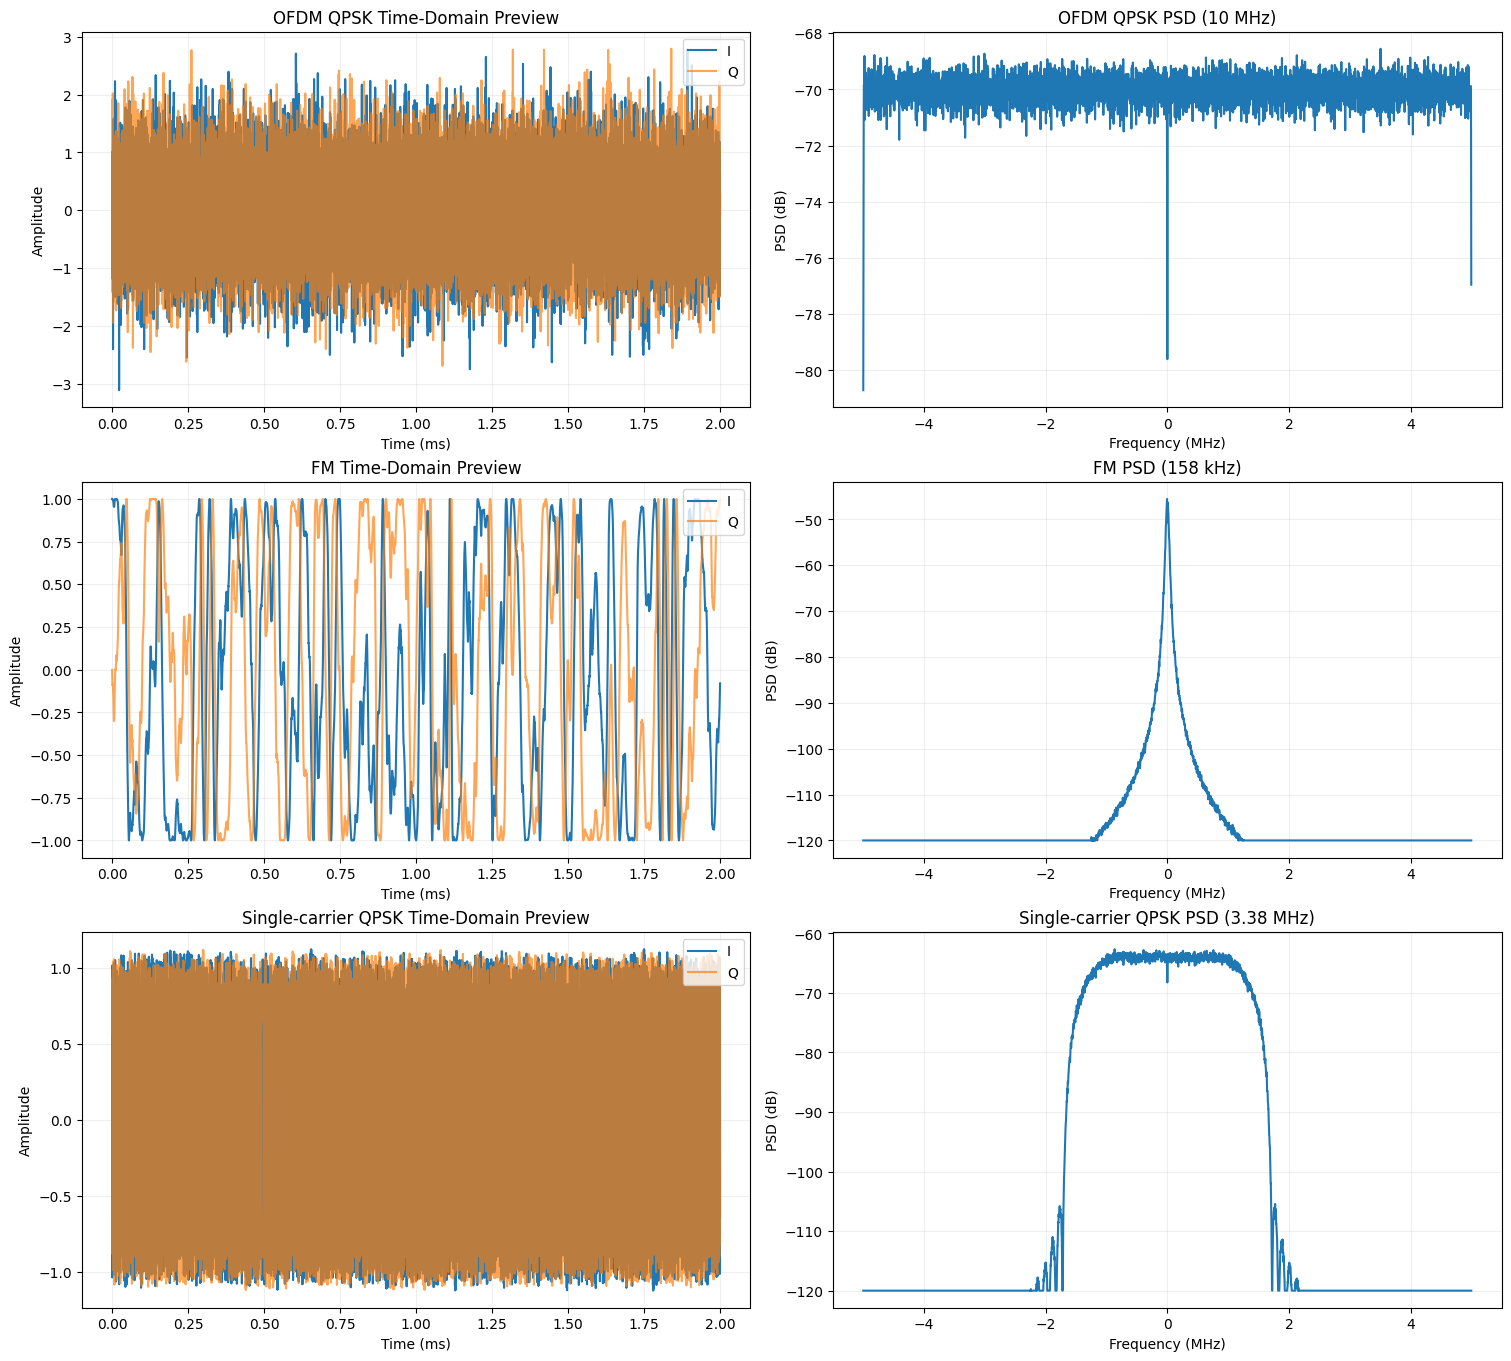

In [3]:
generated_waveforms = [
    ('OFDM QPSK', OFDM_WAVEFORM_PATH, *save_placeholder_waveform(OFDM_WAVEFORM_PATH)),
    ('FM', FM_WAVEFORM_PATH, *save_placeholder_fm_waveform(FM_WAVEFORM_PATH)),
    ('Single-carrier QPSK', QPSK_WAVEFORM_PATH, *save_placeholder_qpsk_waveform(QPSK_WAVEFORM_PATH)),
]

for label, output_path, _, metadata in generated_waveforms:
    print(f'Saved {label} placeholder to {output_path}')
    print('  metadata:', metadata)

fig, axes = plt.subplots(len(generated_waveforms), 2, figsize=(15, 4.5 * len(generated_waveforms)), constrained_layout=True)
for row_index, (label, _, waveform, metadata) in enumerate(generated_waveforms):
    preview_samples = min(len(waveform), 20000)
    welch_freq_hz, welch_psd = signal.welch(
        waveform,
        fs=SOURCE_SAMPLE_RATE_HZ,
        nperseg=4096,
        return_onesided=False,
        scaling='density',
    )
    welch_freq_hz = np.fft.fftshift(welch_freq_hz)
    welch_psd = np.fft.fftshift(welch_psd)

    axes[row_index, 0].plot(np.arange(preview_samples) / SOURCE_SAMPLE_RATE_HZ * 1e3, np.real(waveform[:preview_samples]), label='I')
    axes[row_index, 0].plot(np.arange(preview_samples) / SOURCE_SAMPLE_RATE_HZ * 1e3, np.imag(waveform[:preview_samples]), label='Q', alpha=0.7)
    axes[row_index, 0].set_title(f'{label} Time-Domain Preview')
    axes[row_index, 0].set_xlabel('Time (ms)')
    axes[row_index, 0].set_ylabel('Amplitude')
    axes[row_index, 0].grid(True, alpha=0.2)
    axes[row_index, 0].legend(loc='upper right')

    axes[row_index, 1].plot(welch_freq_hz / 1e6, 10.0 * np.log10(np.maximum(welch_psd, 1e-12)))
    axes[row_index, 1].set_title(f"{label} PSD ({human_hz(float(metadata['bandwidth_hz']))})")
    axes[row_index, 1].set_xlabel('Frequency (MHz)')
    axes[row_index, 1].set_ylabel('PSD (dB)')
    axes[row_index, 1].grid(True, alpha=0.2)

plt.show()

In [4]:
waveform_entries: list[dict[str, object]] = []
for waveform_path in WAVEFORM_PATHS:
    waveform, sample_rate_hz, bandwidth_hz = load_waveform_mat(waveform_path)
    waveform_entries.append({
        'name': waveform_path.stem,
        'path': waveform_path,
        'waveform': waveform,
        'sample_rate_hz': sample_rate_hz,
        'bandwidth_hz': bandwidth_hz,
    })

composite_iq, placements = build_eye_chart_signal(waveform_entries)
sigmf_data_path, sigmf_meta_path = save_sigmf(SIGMF_STEM, composite_iq, placements)

print(f'Composite samples: {len(composite_iq):,}')
print(f'Composite duration: {len(composite_iq) / FINAL_SAMPLE_RATE_HZ:.3f} s')
print(f'Saved SigMF data: {sigmf_data_path}')
print(f'Saved SigMF metadata: {sigmf_meta_path}')
print(f'Annotation count: {len(placements)}')

Composite samples: 100,745,000
Composite duration: 2.015 s
Saved SigMF data: /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/validator_artifacts/rf_seeing_eye_chart/RF_seeing_eye_exam_transmit.sigmf-data
Saved SigMF metadata: /home/sat3737/holoscan_demo_workspace/holohub-dev/notebooks/validator_artifacts/rf_seeing_eye_chart/RF_seeing_eye_exam_transmit.sigmf-meta
Annotation count: 270


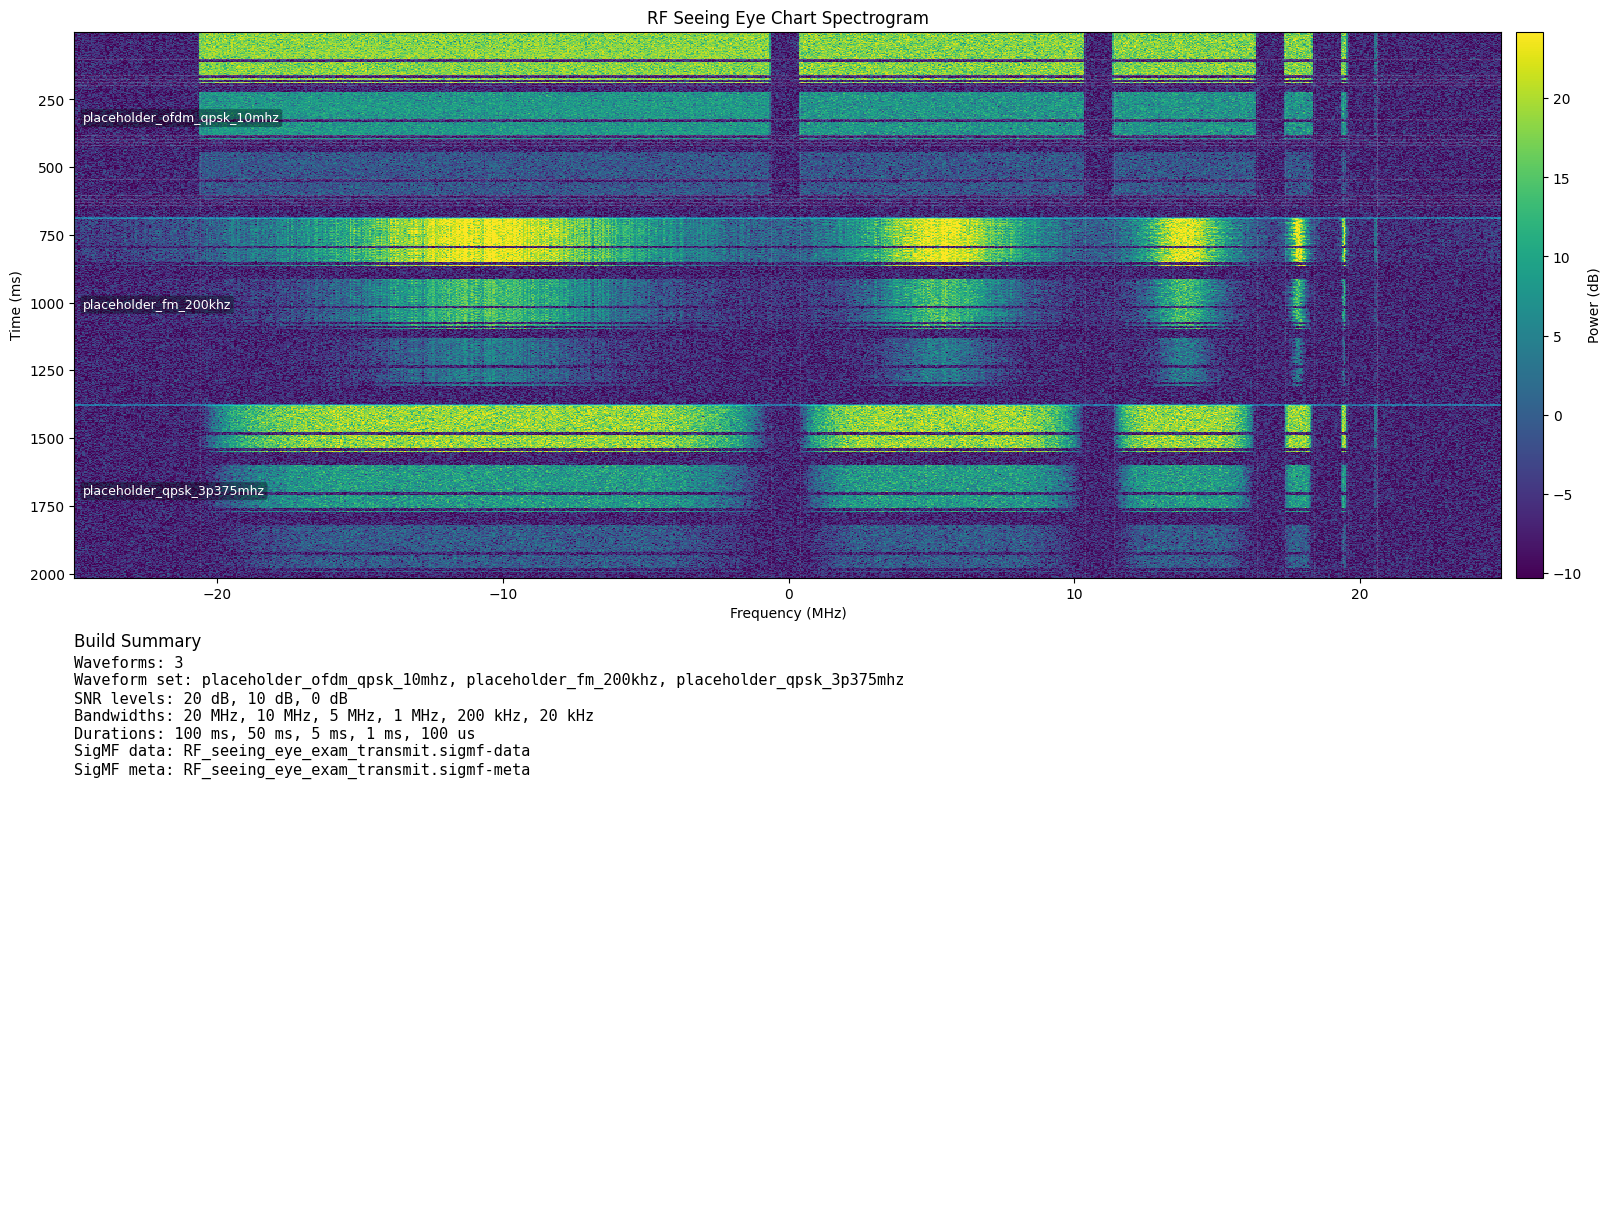

In [5]:
freqs_hz, times_s, spectrogram_db = compute_display_spectrogram(composite_iq, FINAL_SAMPLE_RATE_HZ)
waveform_ranges = []
for waveform_idx, entry in enumerate(waveform_entries):
    waveform_placements = [item for item in placements if item['waveform_index'] == waveform_idx]
    if waveform_placements:
        waveform_ranges.append({
            'name': str(entry['name']),
            'start_s': min(float(item['time_start_s']) for item in waveform_placements),
            'stop_s': max(float(item['time_stop_s']) for item in waveform_placements),
        })

fig, axes = plt.subplots(2, 1, figsize=(16, 12), constrained_layout=True)
extent = [freqs_hz[0] / 1e6, freqs_hz[-1] / 1e6, times_s[-1] * 1e3, times_s[0] * 1e3]
image = axes[0].imshow(
    spectrogram_db,
    extent=extent,
    aspect='auto',
    interpolation='nearest',
    vmin=float(np.percentile(spectrogram_db, 8)),
    vmax=float(np.percentile(spectrogram_db, 99.5)),
)
axes[0].set_title('RF Seeing Eye Chart Spectrogram')
axes[0].set_xlabel('Frequency (MHz)')
axes[0].set_ylabel('Time (ms)')
colorbar = fig.colorbar(image, ax=axes[0], pad=0.01)
colorbar.set_label('Power (dB)')

for center_frequency_hz, bandwidth_hz in zip(CENTER_FREQUENCIES_HZ, BANDWIDTHS_HZ):
    axes[0].axvline((center_frequency_hz - 0.5 * bandwidth_hz) / 1e6, color='white', alpha=0.08, linewidth=0.7)
    axes[0].axvline((center_frequency_hz + 0.5 * bandwidth_hz) / 1e6, color='white', alpha=0.08, linewidth=0.7)

cursor_ms = 0.0
for _ in SNR_DB_LEVELS:
    for pulse_duration_s in PULSE_DURATIONS_S:
        cursor_ms += pulse_duration_s * 1e3
        axes[0].axhline(cursor_ms, color='white', alpha=0.12, linewidth=0.8)
        cursor_ms += ROW_GUARD_S * 1e3
    cursor_ms += (SNR_BLOCK_GUARD_S - ROW_GUARD_S) * 1e3

for range_index, waveform_range in enumerate(waveform_ranges):
    if range_index > 0:
        axes[0].axhline(waveform_range['start_s'] * 1e3, color='cyan', alpha=0.45, linewidth=1.2)
    label_y_ms = 0.5 * (waveform_range['start_s'] + waveform_range['stop_s']) * 1e3
    axes[0].text(
        freqs_hz[0] / 1e6 + 0.3,
        label_y_ms,
        waveform_range['name'],
        color='white',
        fontsize=9,
        va='center',
        ha='left',
        bbox={'boxstyle': 'round,pad=0.2', 'facecolor': 'black', 'alpha': 0.35, 'edgecolor': 'none'},
    )

axes[1].axis('off')
snr_label = ', '.join(f'{value:.0f} dB' for value in SNR_DB_LEVELS)
bandwidth_label = ', '.join(human_hz(value) for value in BANDWIDTHS_HZ)
duration_label = ', '.join(human_time(value) for value in PULSE_DURATIONS_S)
waveform_label = ', '.join(entry['name'] for entry in waveform_entries)
summary_lines = [
    f'Waveforms: {len(waveform_entries)}',
    f'Waveform set: {waveform_label}',
    f'SNR levels: {snr_label}',
    f'Bandwidths: {bandwidth_label}',
    f'Durations: {duration_label}',
    f'SigMF data: {sigmf_data_path.name}',
    f'SigMF meta: {sigmf_meta_path.name}',
]
axes[1].text(0.0, 1.0, '\n'.join(summary_lines), va='top', ha='left', family='monospace', fontsize=11)
axes[1].set_title('Build Summary', loc='left')
plt.show()